In [1]:
import numpy as np
import torch
import torchkbnufft as tkbn
import ptwt
from casacore.tables import table
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

In [11]:
import numpy as np
import torch
from casacore.tables import table

def load_spectral_cube_visibilities(ms_path, spw_idx=0, chan_start=0, chan_end=None, pol_idx=0):
    # ==========================================
    # 1. Extract Frequency Range from Metadata
    # ==========================================
    spw_tb = table(ms_path + '/SPECTRAL_WINDOW', ack=False)
    chan_freqs = spw_tb.getcol('CHAN_FREQ')[spw_idx]
    spw_tb.close()
    
    if chan_end is None:
        chan_end = len(chan_freqs)
        
    selected_freqs = chan_freqs[chan_start:chan_end]
    num_channels = len(selected_freqs)
    
    # Use the median frequency of the selected band to calculate wavelength
    # This narrowband approximation allows us to use one k-trajectory for all channels
    center_frequency = np.median(selected_freqs)
    speed_of_light = 299792458.0 # m/s
    wavelength = speed_of_light / center_frequency
    
    # ==========================================
    # 2. Extract Visibility Cube and UV Coordinates
    # ==========================================
    tb = table(ms_path, ack=False)
    col_names = tb.colnames()
    data_col = 'CORRECTED_DATA' if 'CORRECTED_DATA' in col_names else 'DATA'
    
    # Extract shape: (N_rows, N_channels, N_polarizations)
    data = tb.getcol(data_col)[:, chan_start:chan_end, pol_idx]
    uvw = tb.getcol("UVW")
    flags = tb.getcol("FLAG")[:, chan_start:chan_end, pol_idx]
    tb.close()
    
    # To keep the dirty beam (PSF) constant across the velocity axis, 
    # we only keep baselines that are unflagged across ALL selected channels.
    valid_row_idx = ~np.any(flags, axis=1)
    
    # Extract and transpose so shape becomes (N_channels, N_valid_baselines)
    v_meas = data[valid_row_idx, :].T
    
    u = uvw[valid_row_idx, 0]
    v = uvw[valid_row_idx, 1]
    
    # ==========================================
    # 3. Compute Optimal Cell Size 
    # ==========================================
    max_baseline_meters = np.max(np.sqrt(u**2 + v**2))
    resolution_rad = wavelength / max_baseline_meters
    
    # Oversample the beam to prevent pixelation artifacts
    cell_size_rad = resolution_rad / 8.0
    cell_size_arcsec = cell_size_rad * (180.0 * 3600.0 / np.pi)
    
    print(f"Cube Center Freq:      {center_frequency / 1e9:.4f} GHz")
    print(f"Number of Channels:    {num_channels}")
    print(f"Calculated Cell Size:  {cell_size_arcsec:.4f} arcseconds")
    
    # ==========================================
    # 4. Scale Coordinates for torchkbnufft
    # ==========================================
    u_scaled = (u / wavelength) * cell_size_rad * 2 * np.pi
    v_scaled = (v / wavelength) * cell_size_rad * 2 * np.pi
    
    # Filter baselines exceeding the Nyquist grid
    valid_k = (np.abs(u_scaled) < np.pi) & (np.abs(v_scaled) < np.pi)
    
    u_final = u_scaled[valid_k]
    v_final = v_scaled[valid_k]
    ktraj = np.vstack((u_final, v_final)) 
    
    # Filter the corresponding visibilities
    v_meas_final = v_meas[:, valid_k]
    
    # ==========================================
    # 5. Format for PyTorch Batched Processing
    # ==========================================
    ktraj_tensor = torch.tensor(ktraj, dtype=torch.float32)
    v_meas_tensor = torch.tensor(v_meas_final, dtype=torch.complex64)
    
    # Reshape v_meas to (Batch, Channels, K-points) -> (N_channels, 1, K_points)
    # This prepares it for creating a (Depth, 1, Height, Width) tensor 
    v_batched = v_meas_tensor.unsqueeze(1)
    
    return ktraj_tensor, v_batched, cell_size_arcsec

# Execute and load to GPU
ktraj, v_cube, cell_size_arcsec = load_spectral_cube_visibilities(
    '/Users/arnablahiry/repos/Deconvolver2D1D-ALMA/data/twhya/twhya_calibrated.ms',
    chan_start=150, 
    chan_end=250 # Extract 100 channels around the expected line
)

ktraj = ktraj.to(device)
v_cube = v_cube.to(device)

Cube Center Freq:      372.6549 GHz
Number of Channels:    100
Calculated Cell Size:  0.0563 arcseconds


Generating Dirty Spectral Cube via Adjoint NUFFT...


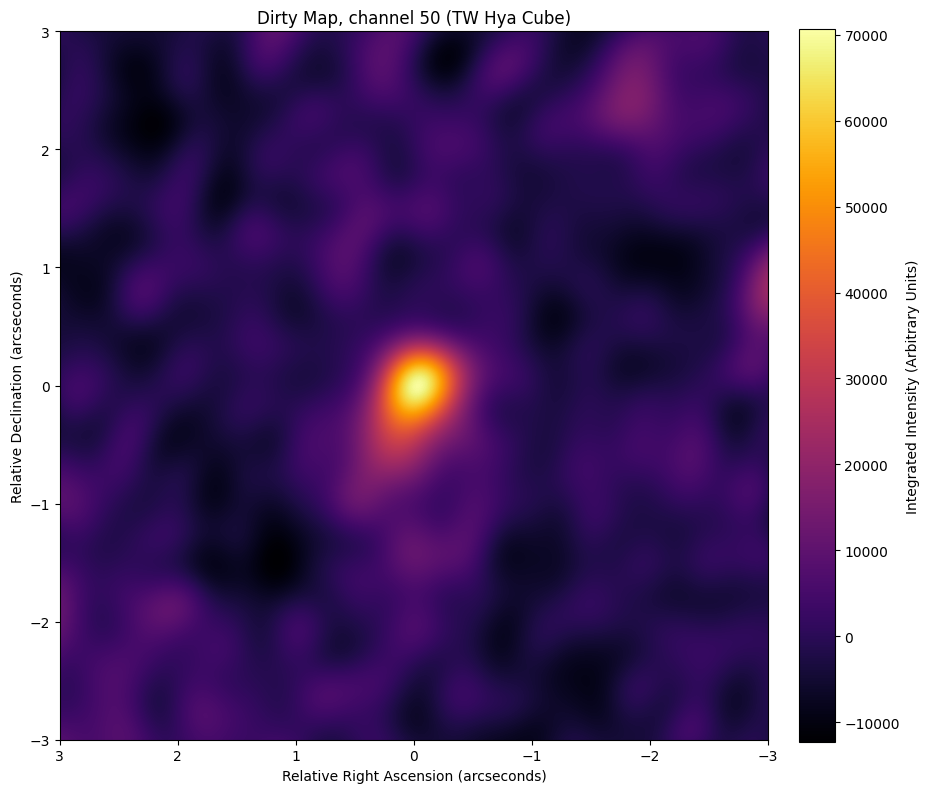

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 2. Setup NUFFT Operator (A)
# ==========================================
im_size = (256, 256) # Reduced grid size for faster cube processing
nufft_ob = tkbn.KbNufft(im_size=im_size).to(device)
adjnufft_ob = tkbn.KbNufftAdjoint(im_size=im_size).to(device)

print("Generating Dirty Spectral Cube via Adjoint NUFFT...")

with torch.no_grad():
    # v_cube is already batched from the loader: (N_channels, 1, K_points)
    # Do NOT unsqueeze it again. Pass it directly.
    dirty_cube_complex = adjnufft_ob(v_cube, ktraj)

    # Real part, not magnitude: the dirty image is real-valued, and abs() would
    # rectify the negative dirty-beam sidelobes that deconvolution has to remove.
    # Shape goes from (N_channels, 1, 256, 256) -> (N_channels, 256, 256)
    dirty_cube_3d = dirty_cube_complex.real.squeeze(1).cpu().numpy()

# Calculate the physical boundaries of the image grid in arcseconds
half_size_arcsec = (im_size[0] / 2.0) * cell_size_arcsec
extent = [half_size_arcsec, -half_size_arcsec, -half_size_arcsec, half_size_arcsec]

plt.figure(figsize=(10, 10))

# Apply bicubic interpolation to smooth the reduced 512x512 grid
plt.imshow(dirty_cube_3d[50], cmap='inferno', origin='lower', extent=extent, interpolation='bicubic')
plt.colorbar(fraction=0.046, pad=0.04, label='Integrated Intensity (Arbitrary Units)')


plt.title('Dirty Map, channel 50 (TW Hya Cube)')
plt.xlabel('Relative Right Ascension (arcseconds)')
plt.ylabel('Relative Declination (arcseconds)')

# Zoom in to the central region
zoom_arcsec = 3.0 
plt.xlim(zoom_arcsec, -zoom_arcsec) # Keep RA inverted
plt.ylim(-zoom_arcsec, zoom_arcsec)

plt.show()

In [13]:
import sys, math, time
sys.path.insert(0, '/Users/arnablahiry/repos/Deconvolver2D1D-ALMA/src')

from wavelet2d1d_torch import prox_2d1d, subband_mad_noise

# ==========================================
# 3a. 2D-1D starlet setup
# ==========================================
# The sparsity prior is the 2D-1D starlet transform (src/wavelet2d1d.py, ported
# to torch in src/wavelet2d1d_torch.py) applied to the whole cube: 2D scales
# over (y, x) capture spatial morphology, 1D scales over the spectral axis
# capture the line profile / kinematics. Sub-band (j2, j1) is the same shape as
# the cube and the sum over all (j2, j1) reconstructs it exactly.
NUM_SCALES_2D = 4    # spatial detail scales (+1 coarse) -> structures up to ~16 px
NUM_SCALES_1D = 3    # spectral detail scales (+1 coarse) -> up to ~8 channels
K_SIGMA = 10.0        # constant k: threshold = K_SIGMA * sigma[j2, j1]

n_chan = v_cube.shape[0]
cube_shape = (n_chan, *im_size)
print(f"Cube shape (nz, ny, nx): {cube_shape}")

# ==========================================
# 3b. Lipschitz constant of the data term
# ==========================================
# f(x) = 0.5 * ||V - A x||^2  =>  grad f = A^H (A x - V), Lipschitz L = ||A^H A||.
# A^H A is identical for every channel (one shared k-trajectory), so estimating
# it on a single plane is enough.
def calculate_lipschitz(nufft_ob, adjnufft_ob, ktraj, im_size, device, num_iters=20):
    print("Calculating Lipschitz constant via Power Iteration...")
    with torch.no_grad():
        x = torch.randn((1, 1, *im_size), device=device) + \
            1j * torch.randn((1, 1, *im_size), device=device)
        x = x / torch.sqrt(torch.sum(x.real**2 + x.imag**2))

        L_est = 0.0
        for i in range(num_iters):
            x_new = adjnufft_ob(nufft_ob(x, ktraj), ktraj)
            norm_x_new = torch.sqrt(torch.sum(x_new.real**2 + x_new.imag**2))
            norm_x = torch.sqrt(torch.sum(x.real**2 + x.imag**2))
            L_est = (norm_x_new / norm_x).item()
            x = x_new / norm_x_new
            if i % 5 == 0 or i == num_iters - 1:
                print(f"  Power Iteration {i:02d}: L = {L_est:.4e}")
    return L_est

L = calculate_lipschitz(nufft_ob, adjnufft_ob, ktraj, im_size, device)
step = 1.0 / L
print(f"\n---> FISTA step size: {step:.4e}\n")

# ==========================================
# 3c. Per-sub-band noise from the dirty cube (MAD)
# ==========================================
# visibilities -> A^H -> real dirty cube -> 2D-1D starlet -> MAD per sub-band.
#
# One scaling detail: A^H is unnormalized, so the raw dirty cube is not in the
# same units as the FISTA iterate X. The prox input is
#   Z = Y - step * A^H (A Y - V),
# which from X = 0 is exactly step * A^H V. So the cube we measure the MAD on
# is the dirty cube times `step`, and the thresholds then land in the same
# units as the coefficients they are compared against. Set DIRTY_SCALE = 1.0
# if you would rather work in raw A^H units throughout.
DIRTY_SCALE = step

with torch.no_grad():
    dirty_prox_units = DIRTY_SCALE * torch.as_tensor(
        dirty_cube_3d, dtype=torch.float32, device=device)
    noise_levels = subband_mad_noise(dirty_prox_units, NUM_SCALES_2D, NUM_SCALES_1D)

thresholds = K_SIGMA * noise_levels

print("Per-sub-band sigma from dirty-cube MAD, threshold = K_SIGMA * sigma")
print("rows: 2D scale (fine -> coarse), cols: 1D scale (fine -> coarse)")
print("last row / last col are the coarse (approximation) scales\n")
for j2 in range(NUM_SCALES_2D + 1):
    print("  " + "  ".join(f"{thresholds[j2, j1].item():.3e}"
                           for j1 in range(NUM_SCALES_1D + 1)))


Cube shape (nz, ny, nx): (100, 256, 256)
Calculating Lipschitz constant via Power Iteration...
  Power Iteration 00: L = 7.7188e+05
  Power Iteration 05: L = 3.1802e+07
  Power Iteration 10: L = 3.2806e+07
  Power Iteration 15: L = 3.3051e+07
  Power Iteration 19: L = 3.3161e+07

---> FISTA step size: 3.0156e-08

Per-sub-band sigma from dirty-cube MAD, threshold = K_SIGMA * sigma
rows: 2D scale (fine -> coarse), cols: 1D scale (fine -> coarse)
last row / last col are the coarse (approximation) scales

  3.700e-05  1.516e-05  9.429e-06  5.609e-05
  1.083e-04  4.430e-05  2.755e-05  1.614e-04
  1.857e-04  7.584e-05  4.711e-05  2.821e-04
  1.680e-04  6.885e-05  4.312e-05  3.187e-04
  1.493e-04  6.054e-05  3.882e-05  4.568e-04


In [14]:
# ==========================================
# 4. FISTA with a 2D-1D starlet prox
# ==========================================
# minimize  0.5 * ||V - A x||^2  +  sum_{j2,j1} thresholds[j2,j1] * ||W_{j2,j1} x||_1
# subject to x >= 0, with x the full (nz, ny, nx) cube.
#
# Differences from the previous 2D db4 version:
#   - the unknown is the whole cube, not one plane, so the prox sees spectral
#     structure and can enforce sparsity jointly in (space, velocity);
#   - the prox is the undecimated 2D-1D starlet with a per-sub-band threshold
#     K_SIGMA * sigma[j2, j1] instead of one global lambda * step;
#   - the gradient is computed in closed form, A^H (A y - V), rather than by
#     autograd through the NUFFT (same value, no graph to build).

NUM_ITERATIONS = 100

# Image variables live as (nz, 1, ny, nx) for torchkbnufft's (batch, coil, y, x)
# convention; the prox works on the (nz, ny, nx) view.
X = torch.zeros((n_chan, 1, *im_size), dtype=torch.float32, device=device)
X_prev = X.clone()
Y = X.clone()
t = 1.0

print(f"--- Starting FISTA ({NUM_ITERATIONS} iterations, "
      f"J2={NUM_SCALES_2D}, J1={NUM_SCALES_1D}, k={K_SIGMA}) ---")
start_time = time.time()

with torch.no_grad():
    for i in range(NUM_ITERATIONS):
        # ---- Step 1: gradient step at the momentum point Y ----
        residual = nufft_ob(Y.to(torch.complex64), ktraj) - v_cube   # A Y - V
        grad = adjnufft_ob(residual, ktraj).real                      # A^H (A Y - V)
        Z = Y - step * grad

        # ---- Step 2: prox = 2D-1D starlet soft threshold at K_SIGMA * sigma ----
        # keep_coarse leaves the (J2, J1) smooth band alone so the cube's
        # large-scale flux is not shrunk away.
        X_new = prox_2d1d(Z.squeeze(1), thresholds,
                          NUM_SCALES_2D, NUM_SCALES_1D,
                          keep_coarse=True).unsqueeze(1)

        # ---- Step 3: positivity ----
        X_new = torch.relu(X_new)

        # ---- Step 4: Nesterov momentum ----
        t_new = (1.0 + math.sqrt(1.0 + 4.0 * t * t)) / 2.0
        Y = X_new + ((t - 1.0) / t_new) * (X_new - X_prev)
        X_prev = X_new
        X = X_new
        t = t_new

        # ---- Step 5: logging ----
        if i % 10 == 0 or i == NUM_ITERATIONS - 1:
            data_loss = 0.5 * torch.sum(residual.real**2 + residual.imag**2).item()
            print(f"Iter {i:04d} | "
                  f"0.5||V-AX||^2: {data_loss:.4e} | "
                  f"active voxels: {(X > 0).float().mean().item() * 100:6.3f}% | "
                  f"max flux: {X.max().item():.4e}")

print(f"--- Optimization complete in {time.time() - start_time:.2f} s ---")

# Deconvolved cube, (nz, ny, nx), on CPU for plotting.
model_cube = X.squeeze(1).cpu().numpy()
print("Deconvolved cube in `model_cube` (and tensor `X`), shape", model_cube.shape)


--- Starting FISTA (100 iterations, J2=4, J1=3, k=10.0) ---
Iter 0000 | 0.5||V-AX||^2: 6.0979e+08 | active voxels: 39.681% | max flux: 1.3368e-03
Iter 0010 | 0.5||V-AX||^2: 6.0583e+08 | active voxels: 91.732% | max flux: 1.5334e-02
Iter 0020 | 0.5||V-AX||^2: 6.0563e+08 | active voxels: 98.649% | max flux: 2.5112e-02
Iter 0030 | 0.5||V-AX||^2: 6.0592e+08 | active voxels: 99.867% | max flux: 3.1993e-02
Iter 0040 | 0.5||V-AX||^2: 6.0634e+08 | active voxels: 99.973% | max flux: 3.7752e-02
Iter 0050 | 0.5||V-AX||^2: 6.0658e+08 | active voxels: 99.960% | max flux: 4.3175e-02
Iter 0060 | 0.5||V-AX||^2: 6.0662e+08 | active voxels: 99.953% | max flux: 4.7300e-02
Iter 0070 | 0.5||V-AX||^2: 6.0651e+08 | active voxels: 99.943% | max flux: 5.0711e-02
Iter 0080 | 0.5||V-AX||^2: 6.0638e+08 | active voxels: 99.938% | max flux: 5.3414e-02
Iter 0090 | 0.5||V-AX||^2: 6.0630e+08 | active voxels: 99.937% | max flux: 5.5702e-02
Iter 0099 | 0.5||V-AX||^2: 6.0631e+08 | active voxels: 99.936% | max flux: 5.761

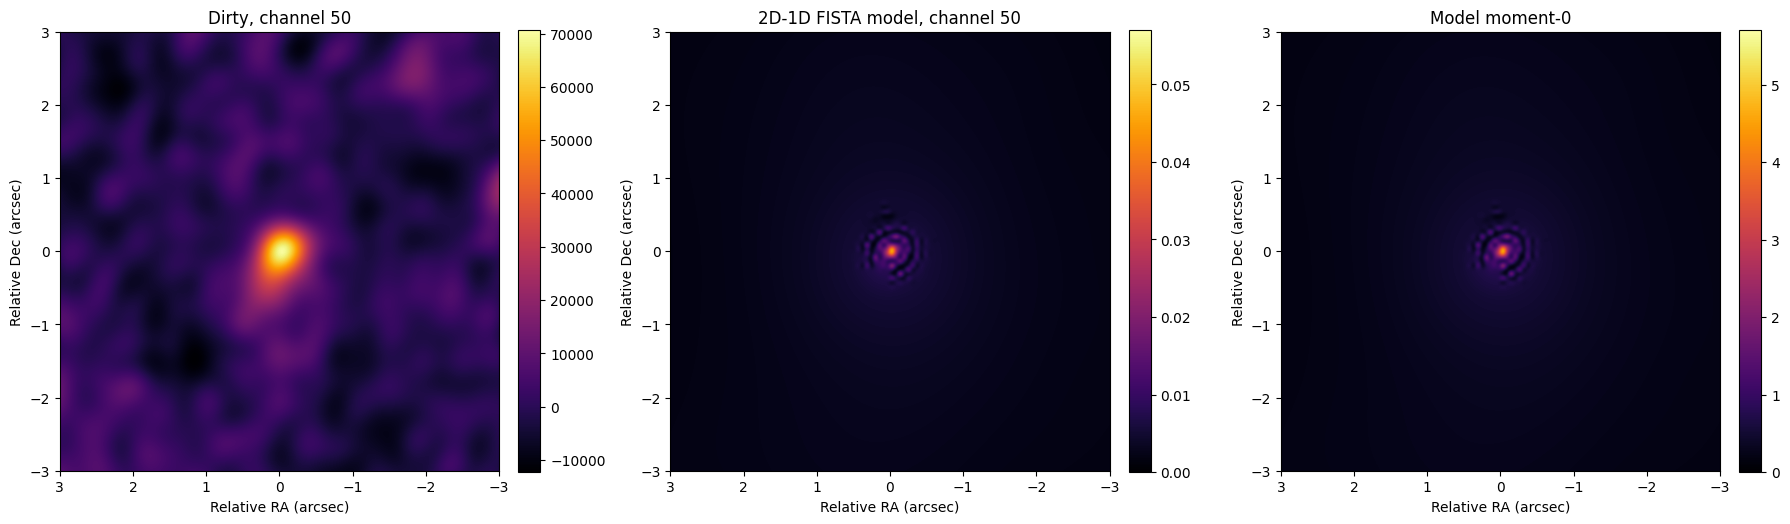

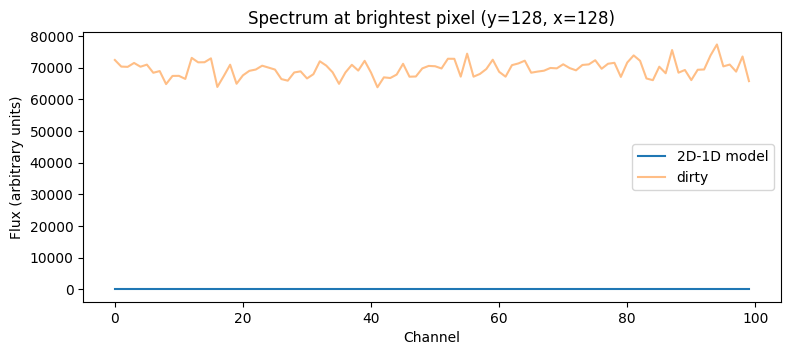

In [15]:
import matplotlib.pyplot as plt

chan = model_cube.shape[0] // 2
half = (im_size[0] / 2.0) * cell_size_arcsec
extent = [half, -half, -half, half]
zoom = 3.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, img, title in [
    (axes[0], dirty_cube_3d[chan], f'Dirty, channel {chan}'),
    (axes[1], model_cube[chan], f'2D-1D FISTA model, channel {chan}'),
    (axes[2], model_cube.sum(axis=0), 'Model moment-0'),
]:
    im = ax.imshow(img, cmap='inferno', origin='lower', extent=extent,
                   interpolation='bicubic')
    ax.set_title(title)
    ax.set_xlabel('Relative RA (arcsec)')
    ax.set_ylabel('Relative Dec (arcsec)')
    ax.set_xlim(zoom, -zoom)
    ax.set_ylim(-zoom, zoom)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Spectrum through the brightest spatial pixel of the model: this is the axis
# the 1D half of the transform regularizes.
yy, xx = np.unravel_index(np.argmax(model_cube.sum(axis=0)), model_cube.shape[1:])
plt.figure(figsize=(9, 3.5))
plt.plot(model_cube[:, yy, xx], label='2D-1D model')
plt.plot(dirty_cube_3d[:, yy, xx], alpha=0.5, label='dirty')
plt.xlabel('Channel')
plt.ylabel('Flux (arbitrary units)')
plt.title(f'Spectrum at brightest pixel (y={yy}, x={xx})')
plt.legend()
plt.show()
